In [56]:
import pandas as pd

df = pd.read_csv('./output/ecoli_test.tsv', sep='\t')

In [57]:
df.head()

,key,consensus_value,homopolymer_length,consensus_count,neighbor_count,total_count,SUBSTITUTION(AC),SUBSTITUTION(AG),SUBSTITUTION(AT),SUBSTITUTION(GA),...,SUBSTITUTION(TG),INSERTION(A),INSERTION(C),INSERTION(G),INSERTION(T),DELETION(A),DELETION(C),DELETION(G),DELETION(T),AMBIGUOUS
0,CGACATCTCTTCTTCGTTGAG,CGGATC,2,8,3,11,0,0,0,0,...,0,0,1,0,0,1,0,0,0,1
1,TGGCAATATGCTGTTTATGGC,GTTAAT,2,6,3,9,0,0,0,0,...,0,0,1,0,0,0,0,0,1,1
2,TCATCAAGGCTTTCCAGCTTT,GCCAGC,3,5,1,6,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
3,ACCGAGCAAAATAACTTCACA,AGGCGC,2,5,1,6,0,0,0,0,...,0,1,0,0,0,0,0,0,0,0
4,AGCGACAGATGAGCTGATTGC,CGCCGT,2,8,1,9,0,0,0,0,...,0,1,0,0,0,0,0,0,0,0


In [33]:
df['SUBSTITUTION'] = df[[col for col in df.columns if col.startswith('SUBSTITUTION')]].sum(axis=1)
df['INSERTION'] = df[[col for col in df.columns if col.startswith('INSERTION')]].sum(axis=1)
df['DELETION'] = df[[col for col in df.columns if col.startswith('DELETION')]].sum(axis=1)

In [34]:
df['non_substitution_neighbors'] = df['neighbor_count'] + df['consensus_count'] - df['SUBSTITUTION']
df['non_insertion_neighbors'] = df['neighbor_count'] + df['consensus_count'] - df['INSERTION']
df['non_deletion_neighbors'] = df['neighbor_count'] + df['consensus_count'] - df['DELETION']

In [59]:
df['ratio'] = df['neighbor_count'] / df['consensus_count'] / 6

<Axes: xlabel='ratio', ylabel='Count'>

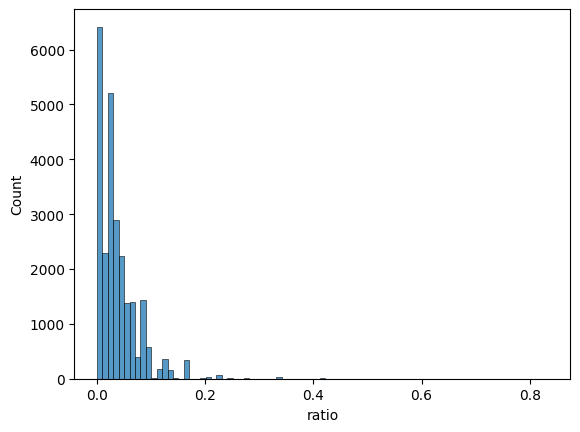

In [62]:
import seaborn as sns

sns.histplot(df["ratio"], binwidth=0.01)

<Axes: xlabel='ratio', ylabel='Density'>

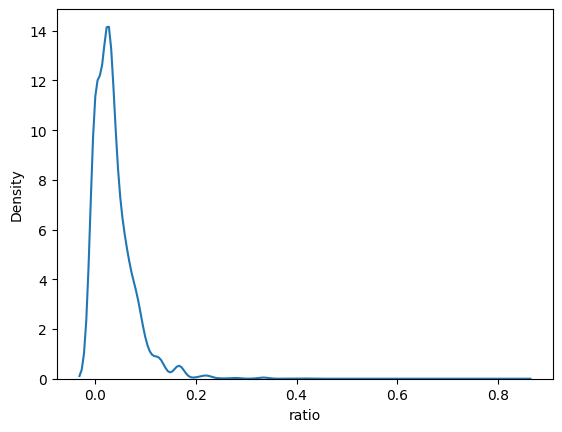

In [67]:
sns.kdeplot(df["ratio"], bw_adjust=2)

In [ ]:
import numpy as np
from scipy import optimize
from scipy import stats


# Generate some random data
#shape, loc, scale = .5, 3, 10
#n = 1000
#data = np.sort(stats.lognorm.rvs(shape, loc, scale, size=n))

kernel = stats.gaussian_kde(df["ratio"])
# Minimize the negative instead of maximizing
# Depending on the shape of your data, you might want to set some bounds
opt = optimize.minimize_scalar(lambda x: -kernel(x))
opt

In [12]:
df[df["ratio"] > 1]

,key,consensus_value,homopolymer_length,consensus_count,neighbor_count,total_count,SUBSTITUTION(AC),SUBSTITUTION(AG),SUBSTITUTION(AT),SUBSTITUTION(GA),...,DELETION(G),DELETION(T),AMBIGUOUS,SUBSTITUTION,INSERTION,DELETION,non_substitution_neighbors,non_insertion_neighbors,non_deletion_neighbors,ratio
80,AAAAAGAGCACATCTCTCATG,AAATGT,3,3,4,8,0,0,0,1,...,0,0,0,2,1,1,5,6,6,1.333333
223,GTGCAAATAACACCGCAAAGA,ATATGC,2,3,4,7,0,0,0,0,...,0,1,0,0,2,2,7,5,5,1.333333
429,GCCGTTAATCCTGATGCTCGG,CTCGCT,2,2,4,6,0,0,0,0,...,1,0,1,2,0,1,4,6,5,2.000000
545,CGTGTGCTTGCTGCGGTATGC,CAGCCG,2,3,5,8,0,0,0,0,...,0,0,2,0,1,2,8,7,6,1.666667
561,ACGCGTAAAGTCGGACGCAAA,GTGCGT,3,2,4,6,0,0,0,0,...,0,0,1,1,1,1,5,5,5,2.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
24441,AATAGTGCCCCCGTGTACATC,CACTAT,2,3,4,8,0,0,0,0,...,0,0,1,1,2,0,6,5,7,1.333333
24461,GTACCCGCGTTAGAGGTTGAA,ACGATA,3,3,4,7,0,0,1,0,...,0,0,1,1,1,1,6,6,6,1.333333
24540,CAGCAGCGGGCTATTTTCCTT,TGTGCT,3,4,5,9,0,0,0,0,...,0,0,2,1,2,0,8,7,9,1.250000
25161,CTTTAGTCAGGCCGTGGAATT,CCGGAG,2,5,6,11,0,0,0,0,...,0,0,2,3,1,0,8,10,11,1.200000


In [42]:
import seaborn as sns
import numpy as np

temp_df = df#[df["Consensus_Count"] > 10]
sns.scatterplot(data=temp_df, x="SUBSTITUTION", y="non_substitution_neighbors", alpha=0.1)

ValueError: Could not interpret value `SUBSTITUTION` for `x`. An entry with this name does not appear in `data`.

<Axes: xlabel='homopolymer_length', ylabel='ratio'>

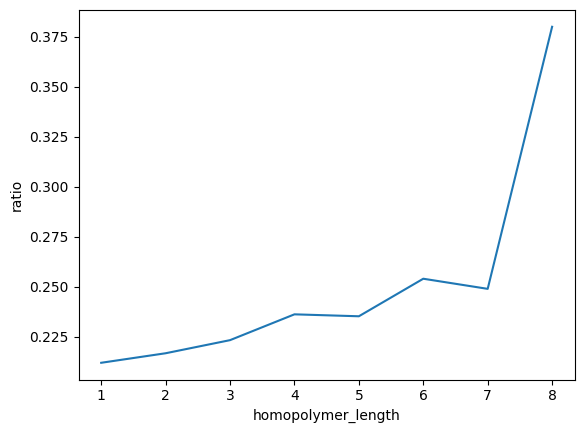

In [14]:
# Plot average ratio w.r.t. homopolymer length
avg_ratio = df.groupby("homopolymer_length")["ratio"].mean().reset_index()
sns.lineplot(data=avg_ratio, x="homopolymer_length", y="ratio")

In [29]:
df[df["Homopolymer_Length"] == 12]

,Key,Consensus_Value,Consensus_Count,Error_Count,Total_Count,Homopolymer_Length,ratio,pred
19072,AAATCAAATGTTTTTTTTTTT,TGCTGA,4,3,21,12,0.75,0.837364


In [53]:
df[df["total_count"] > 20]["ratio"].mean() / 6

np.float64(0.041181346065236726)

In [55]:
len(df[df["Total_Count"] > 50])

96

/tmp/ipykernel_15602/1553159645.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  temp_df["pred"] = model.predict(temp_df[["consensus_count"]])


<Axes: xlabel='consensus_count', ylabel='neighbor_count'>

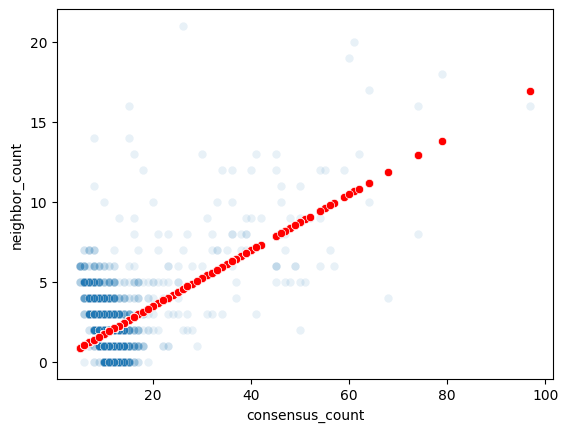

In [54]:
# Linear regression of Error_Count ~ Consensus_Count

from sklearn.linear_model import LinearRegression, QuantileRegressor
import matplotlib.pyplot as plt
temp_df = df[df["total_count"] > 10]
y = temp_df["neighbor_count"]

model = LinearRegression(fit_intercept=False)
model.fit(temp_df[["consensus_count"]], y)
temp_df["pred"] = model.predict(temp_df[["consensus_count"]])
sns.scatterplot(data=temp_df, x="consensus_count", y=y, alpha=0.1)
sns.scatterplot(data=temp_df, x="consensus_count", y="pred", color='red')


/tmp/ipykernel_15602/2481163998.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  temp_df["pred"] = model.predict(temp_df[["non_deletion_neighbors"]])


<Axes: xlabel='non_deletion_neighbors', ylabel='DELETION'>

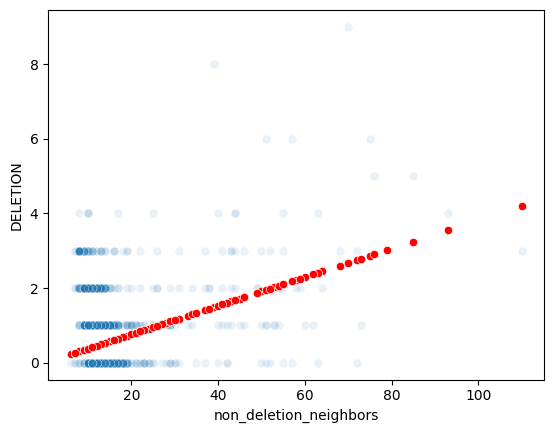

In [26]:
from sklearn.linear_model import LinearRegression, QuantileRegressor
import matplotlib.pyplot as plt
temp_df = df[df["total_count"] > 10]
y = temp_df["DELETION"] #+ temp_df["AMBIGUOUS"]

model = LinearRegression(fit_intercept=False)
model.fit(temp_df[["non_deletion_neighbors"]], y)
temp_df["pred"] = model.predict(temp_df[["non_deletion_neighbors"]])
sns.scatterplot(data=temp_df, x="non_deletion_neighbors", y=y, alpha=0.1)
sns.scatterplot(data=temp_df, x="non_deletion_neighbors", y="pred", color='red')

In [ ]:
model.coef_, model.intercept_

(array([0.17462812]), 0.0)

Bad pipe message: %s [b'@\xd1\xbf\xd5\xe62\xba\xc1\n\xd0\x82\xa5\xe1Eg`\x96\xb7\x00\x02\xbc\x00\x00\x00\x01\x00\x02\x00\x03\x00\x04\x00\x05\x00\x06\x00\x07\x00\x08\x00\t\x00\n\x00\x0b\x00\x0c\x00\r\x00\x0e\x00\x0f\x00\x10\x00\x11\x00\x12\x00\x13']
Bad pipe message: %s [b'"<\xe8zu\x1aQ\xb6\xc8f\x1d\xcd\xddu P\x1c\xb4\x00\x02\xbc\x00\x00\x00\x01\x00\x02\x00\x03\x00\x04\x00\x05\x00\x06\x00\x07\x00\x08\x00\t\x00\n\x00\x0b\x00\x0c\x00\r\x00\x0e\x00\x0f\x00\x10\x00\x11\x00\x12\x00\x13\x00\x14\x00\x15\x00\x16\x00\x17\x00\x18\x00\x19\x00\x1a\x00\x1b\x00\x1e\x00\x1f\x00 \x00!\x00"\x00#\x00$\x00%\x00&\x00\'\x00(\x00)\x00*\x00+\x00,\x00-\x00.\x00/\x000\x001\x002\x003\x004\x005\x006\x007\x008\x009\x00:\x00;\x00<\x00=\x00>\x00?\x00@\x00A\x00B\x00C\x00D\x00E\x00F\x00g\x00h\x00i\x00j\x00k\x00l\x00m\x00\x84\x00\x85\x00\x86\x00\x87\x00\x88\x00\x89\x00\x8a\x00\x8b\x00\x8c\x00\x8d\x00\x8e\x00\x8f\x00\x90\x00\x91\x00\x92\x00\x93\x00\x94\x00\x95\x00\x96\x00\x97\x00\x98\x00\x99\x00\x9a\x00\x9b\x00\x9c\x00\x

In [40]:
1 - (1 / 0.47914946) ** (1/6)

-0.13045904437993983

In [45]:
0.17462812 / 6

0.029104686666666667

In [39]:
0.47914946 / 6

0.07985824333333334

In [32]:
0.17460683 / 6

0.029101138333333332

In [35]:
0.08786134 / 6

0.014643556666666667

/tmp/ipykernel_4965/3106696079.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  temp_df["pred"] = model.predict(temp_df[["Consensus_Count"]])


<Axes: xlabel='Consensus_Count', ylabel='Error_Count'>

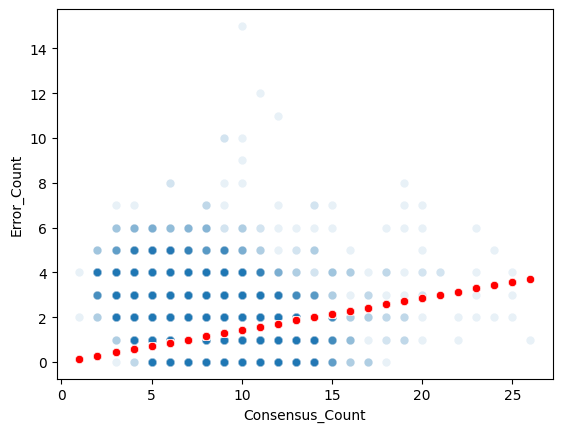

In [260]:
from sklearn.linear_model import LinearRegression, QuantileRegressor

y = temp_df["Error_Count"]

model = QuantileRegressor(quantile=0.5, alpha=1e-6, fit_intercept=False, solver="highs-ds")
model.fit(temp_df[["Consensus_Count"]], y)
temp_df["pred"] = model.predict(temp_df[["Consensus_Count"]])
sns.scatterplot(data=temp_df, x="Consensus_Count", y=y, alpha=0.1)
sns.scatterplot(data=temp_df, x="Consensus_Count", y="pred", color='red')

In [261]:
model.coef_, model.intercept_

(array([0.14285714]), 0.0)

In [215]:
0.15384615 / 6

0.025641024999999998

In [176]:
import torch

def lad_pseudo_huber(X, y, delta=0.01, lr=0.1, steps=2000, l2=0.0, use_lbfgs=False, seed=0, standardize=True):
    torch.manual_seed(seed)
    X = torch.as_tensor(X, dtype=torch.float32)
    y = torch.as_tensor(y, dtype=torch.float32).view(-1)

    # Standardize
    if standardize:
        mu = X.mean(0, keepdim=True)
        sigma = X.std(0, keepdim=True) + 1e-12
        Xs = (X - mu) / sigma
    else:
        mu = torch.zeros(1, X.shape[1]); sigma = torch.ones(1, X.shape[1]); Xs = X

    d = X.shape[1]
    b = torch.zeros(d, requires_grad=True)

    def loss_fn():
        r = y - (Xs @ b)
        # pseudo-Huber
        ph = delta**2 * (torch.sqrt(1.0 + (r/delta)**2) - 1.0)
        reg = 0.5 * l2 * (b @ b)
        return ph.mean() + reg

    if use_lbfgs:
        opt = torch.optim.LBFGS([b], max_iter=200, line_search_fn="strong_wolfe")
        def closure():
            opt.zero_grad()
            L = loss_fn()
            L.backward()
            return L
        for _ in range(20):
            opt.step(closure)
    else:
        opt = torch.optim.Adam([b], lr=lr)
        for _ in range(steps):
            opt.zero_grad()
            L = loss_fn()
            L.backward()
            opt.step()

    # De-standardize
    b_unscaled = (b / sigma.squeeze()).detach().numpy()
    return b_unscaled
    return b0_unscaled, b_unscaled

In [177]:
lad_pseudo_huber(temp_df[["Consensus_Count"]].values, temp_df["Error_Count"].values, delta=1.0, lr=0.1, steps=2000, l2=0.0, use_lbfgs=False, seed=0, standardize=True)

array([0.05126309], dtype=float32)

In [114]:
0.125 / 6

0.020833333333333332